**Name:** Sneha Mahendra Kamble.<br>
**PRN :** 124B2B030<br>
**Title:**  Select/download dataset from UCI/Kaggle or any other repository. Perform data cleaning and exploratory
data analysis (EDA) to gain insights from data
Data cleaning can be following but not limited to:
1. Handle missing values
2. Detect and treat outliers
3. Convert categorical data to numerical
4. Plot distributions
5. Analyze data using correlation
6. Feature selection


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, chi2
from sklearn.feature_selection import SelectPercentile


In [ ]:
df=pd.read_csv("/content/smartphone.csv");
df

,brand_name,model,price,rating,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,...,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height
0,oneplus,OnePlus 11 5G,54999,89.0,snapdragon,8.0,3.20,5000.0,100.0,12,...,120,3,1.0,android,50.0,16.0,0,NaN,1440,3216
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,snapdragon,8.0,2.20,5000.0,33.0,6,...,120,3,1.0,android,64.0,16.0,1,1024.0,1080,2412
2,samsung,Samsung Galaxy A14 5G,16499,75.0,exynos,8.0,2.40,5000.0,15.0,4,...,90,3,1.0,android,50.0,13.0,1,1024.0,1080,2408
3,motorola,Motorola Moto G62 5G,14999,81.0,snapdragon,8.0,2.20,5000.0,NaN,6,...,120,3,1.0,android,50.0,16.0,1,1024.0,1080,2400
4,realme,Realme 10 Pro Plus,24999,82.0,dimensity,8.0,2.60,5000.0,67.0,6,...,120,3,1.0,android,108.0,16.0,0,NaN,1080,2412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,motorola,Motorola Moto Edge S30 Pro,34990,83.0,snapdragon,8.0,3.00,5000.0,68.0,8,...,120,3,1.0,android,64.0,16.0,0,NaN,1080,2460
976,honor,Honor X8 5G,14990,75.0,snapdragon,8.0,2.20,5000.0,22.0,6,...,60,3,1.0,android,48.0,8.0,1,1024.0,720,1600
977,poco,POCO X4 GT 5G (8GB RAM + 256GB),28990,85.0,dimensity,8.0,2.85,5080.0,67.0,8,...,144,3,1.0,android,64.0,16.0,0,NaN,1080,2460
978,motorola,Motorola Moto G91 5G,19990,80.0,snapdragon,8.0,2.20,5000.0,NaN,6,...,60,3,1.0,android,108.0,32.0,1,1024.0,1080,2400


In [ ]:
df.tail(2)

,brand_name,model,price,rating,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,...,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height
978,motorola,Motorola Moto G91 5G,19990,80.0,snapdragon,8.0,2.2,5000.0,NaN,6,...,60,3,1.0,android,108.0,32.0,1,1024.0,1080,2400
979,samsung,Samsung Galaxy M52s 5G,24990,74.0,NaN,8.0,NaN,5000.0,NaN,8,...,60,3,1.0,android,64.0,32.0,1,1024.0,1080,2400


**df.tail(2)** shows the last 2 rows of the dataframe

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   processor_brand            960 non-null    object 
 5   num_cores                  974 non-null    float64
 6   processor_speed            938 non-null    float64
 7   battery_capacity           969 non-null    float64
 8   fast_charging              769 non-null    float64
 9   ram_capacity               980 non-null    int64  
 10  internal_memory            980 non-null    int64  
 11  screen_size                980 non-null    float64
 12  refresh_rate               980 non-null    int64  
 13  num_rear_cameras           980 non-null    int64  

**df.info()** gives a quick summary of your dataframe.

It shows:<br>
Number of rows and columns<br>
Column names<br>
Non-nullcounts <br>
Data types of each column (int, float, object, etc.)<br>
Memory usage<br>

In [ ]:
df.describe()

,price,rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height
count,980.000000,879.000000,974.000000,938.000000,969.000000,769.000000,980.000000,980.000000,980.000000,980.000000,980.000000,976.000000,980.000000,975.000000,980.000000,500.000000,980.000000,980.000000
mean,32520.504082,78.258248,7.772074,2.427217,4817.748194,46.126138,6.560204,141.036735,6.536765,92.256122,2.814286,1.029713,50.319286,16.589128,0.630612,736.064000,1075.852041,2214.663265
std,39531.812669,7.402854,0.836845,0.464090,1009.540054,34.277870,2.744378,107.134516,0.349162,28.988052,0.776441,0.169882,33.000968,10.876802,0.482885,366.894911,290.164931,516.484254
min,3499.000000,60.000000,4.000000,1.200000,1821.000000,10.000000,1.000000,8.000000,3.540000,60.000000,1.000000,1.000000,2.000000,0.300000,0.000000,32.000000,480.000000,480.000000
25%,12999.000000,74.000000,8.000000,2.050000,4500.000000,18.000000,4.000000,64.000000,6.500000,60.000000,2.000000,1.000000,24.000000,8.000000,0.000000,512.000000,1080.000000,1612.000000
50%,19994.500000,80.000000,8.000000,2.300000,5000.000000,33.000000,6.000000,128.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000,1.000000,1024.000000,1080.000000,2400.000000
75%,35491.500000,84.000000,8.000000,2.840000,5000.000000,66.000000,8.000000,128.000000,6.670000,120.000000,3.000000,1.000000,64.000000,16.000000,1.000000,1024.000000,1080.000000,2408.000000
max,650000.000000,89.000000,8.000000,3.220000,22000.000000,240.000000,18.000000,1024.000000,8.030000,240.000000,4.000000,2.000000,200.000000,60.000000,1.000000,2048.000000,2460.000000,3840.000000


df.describe() generates summary statistics for the numerical columns

In [ ]:
df.shape


(980, 22)

**df.shape** gives the dimensions of your dataframe as a tuple

In [ ]:
df.dtypes


,0
brand_name,object
model,object
price,int64
rating,float64
processor_brand,object
num_cores,float64
processor_speed,float64
battery_capacity,float64
fast_charging,float64
ram_capacity,int64


**df.dtypes** shows the data type of each column in your dataframe.

In [ ]:
df.columns

Index(['brand_name', 'model', 'price', 'rating', 'processor_brand',
       'num_cores', 'processor_speed', 'battery_capacity', 'fast_charging',
       'ram_capacity', 'internal_memory', 'screen_size', 'refresh_rate',
       'num_rear_cameras', 'num_front_cameras', 'os', 'primary_camera_rear',
       'primary_camera_front', 'extended_memory_available', 'extended_upto',
       'resolution_width', 'resolution_height'],
      dtype='object')

**df.columns** returns the list (an index object) of all column names in your dataframe.

In [ ]:
print("\nUnique values per column:")
print(df.nunique())



Unique values per column:
brand_name                    46
model                        980
price                        379
rating                        30
processor_brand               13
num_cores                      3
processor_speed               35
battery_capacity              89
fast_charging                 32
ram_capacity                   9
internal_memory                8
screen_size                   79
refresh_rate                   6
num_rear_cameras               4
num_front_cameras              2
os                             3
primary_camera_rear           18
primary_camera_front          24
extended_memory_available      2
extended_upto                  7
resolution_width              40
resolution_height             65
dtype: int64


**df.nunique()** number of unique values in each column of your dataframe.

In [ ]:
df["model"].value_counts()

,count
model,
Samsung Galaxy M52s 5G,1
OnePlus 11 5G,1
OnePlus Nord CE 2 Lite 5G,1
Samsung Galaxy A14 5G,1
Lava X3,1
...,...
Nothing Phone 1,1
Xiaomi Redmi Note 12 Pro Plus,1
Apple iPhone 14,1


**df["model"].value_counts()** will show how many times each unique value appears in the model column.

In [ ]:
# detecting null values
df.isnull().sum()
# df.dropna()
# df.fillna(0,inplace=True)
# df.fillna(method='ffill')
# df['rating'].fillna(df['rating'].mean(),inplace=True)

,0
brand_name,0
model,0
price,0
rating,101
processor_brand,20
num_cores,6
processor_speed,42
battery_capacity,11
fast_charging,211
ram_capacity,0


Most columns are clean, but some have missing values: rating (101), processor_speed (42), fast_charging (211), os (14), and extended_upto (480). Numeric columns can use mean/median fill, categorical columns can use mode

In [ ]:
# bcoz it has too many null values
df.drop('extended_upto', axis=1, inplace=True)


In [ ]:
# Handling null values
num_cols = ['rating', 'num_cores', 'processor_speed', 'battery_capacity', 'num_front_cameras', 'primary_camera_front']
cat_cols = ['processor_brand', 'fast_charging', 'os']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent',fill_value=None)

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isna().sum()

,0
brand_name,0
model,0
price,0
rating,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging,0
ram_capacity,0


In [ ]:
# Removing duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

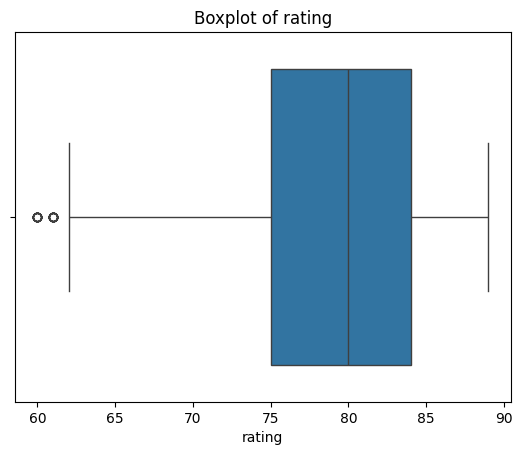

In [ ]:
sns.boxplot(x=df["rating"])
plt.title("Boxplot of rating")
plt.show()


**Central range:** Most ratings lie roughly between 75 and 85.<br>
**Median:** The median rating is around 80, indicating the middle value of the dataset.<br>
**Outliers:** There are a few low outliers around 60–65 on the lower side.<br>
**Spread:** The interquartile range (IQR) is moderate, suggesting ratings are relatively consistent with a few exceptions.<br>
**Skewness**: Slight left skew because of lower outliers.<br>

In [ ]:
multiplier = 0.5

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - multiplier * IQR
upper_bound = Q3 + multiplier * IQR

outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)

df = df[~outliers.any(axis=1)]


Q1 is the 25th percentile of each numeric column.

Q3 is the 75th percentile of each numeric column

~ negates it, so only rows without outliers are kept in the DataFrame.

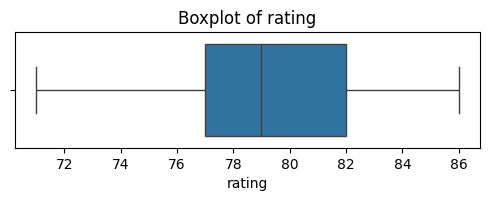

In [ ]:
plt.figure(figsize=(6, 1.5))
sns.boxplot(x=df["rating"])
plt.title("Boxplot of rating")
plt.show()


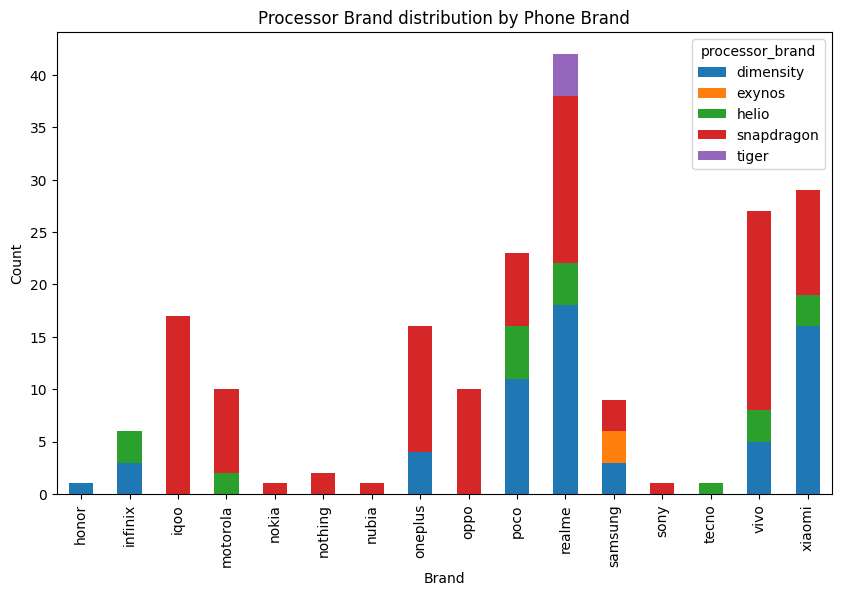

In [ ]:
pd.crosstab(df['brand_name'], df['processor_brand']).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Processor Brand distribution by Phone Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()



Most brands mainly use Snapdragon processors. Some use Dimensity or others for certain models. Samsung mostly uses Exynos, while Realme and Xiaomi use a mix of different processors.

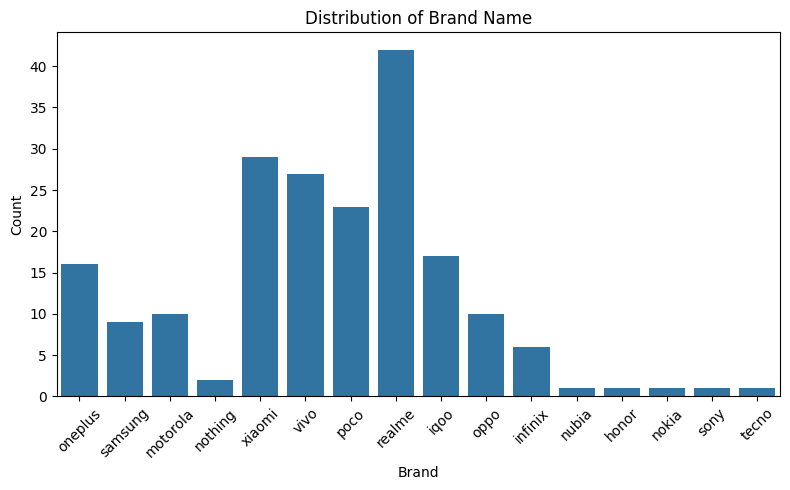

In [ ]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='brand_name')
plt.title("Distribution of Brand Name")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



 **Realme** has the highest number of models in the dataset.<br>
**Xiaomi, Vivo, and Poco** also have a significant presence.
**OnePlus, Samsung, Motorola, and iQOO** have moderate representation.<br>
 Brands like **Nothing, Oppo, Infinix, Nubia, Honor, Nokia, Sony, and Tecno** have very few models.


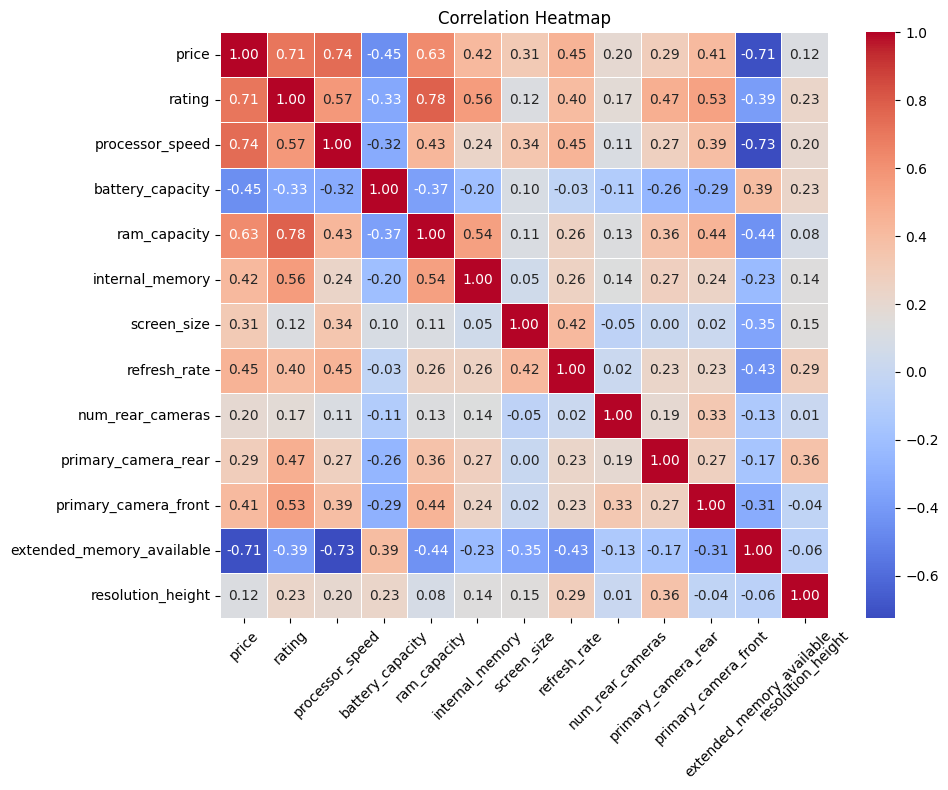

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Remove columns with only 1 unique value (they have no variance)
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Price has a strong positive correlation with processor_speed (0.74), rating (0.71), and ram_capacity (0.63), indicating higher-priced phones tend to have faster processors, better ratings, and more RAM.

Rating is positively correlated with ram_capacity (0.78) and internal_memory (0.56).

Battery_capacity shows a moderate negative correlation with price (-0.45) and rating (-0.33), suggesting higher-priced phones may not always have the largest batteries.

Extended_memory_available has strong negative correlations with price (-0.71) and processor_speed (-0.73), meaning cheaper or less powerful phones are more likely to have expandable storage.

Screen_size, refresh_rate, and number of cameras show weak to moderate correlations with other features, indicating they are somewhat independent of price and performance.

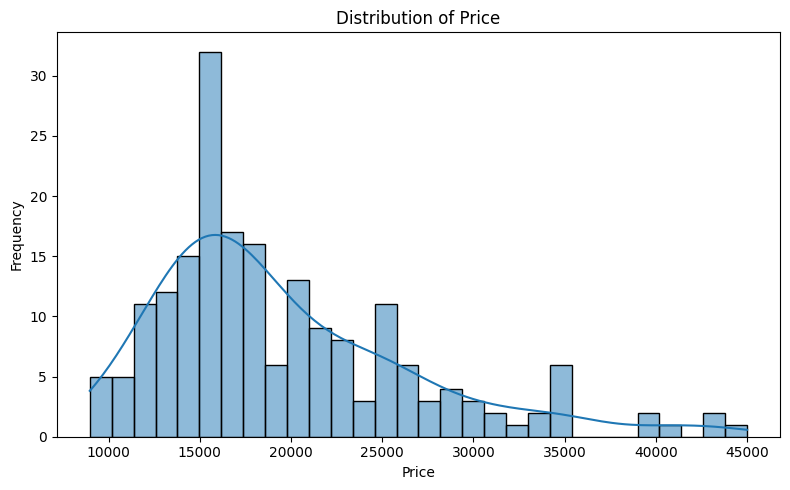

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, bins=30)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


The price distribution is right-skewed, with most items clustered around 15,000–17,000. Prices range widely from 9,000 to 45,000, and a few items above 35,000 act as outliers. The distribution is unimodal, peaking around 16,000, and the density curve confirms the skew and central concentration.

In [ ]:
# Encoding Categorical variables
le = LabelEncoder()
df['fast_charging'] = le.fit_transform(df['fast_charging'])

onehot_cols = ['brand_name', 'processor_brand', 'os']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=False)

/tmp/ipython-input-1767765248.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fast_charging'] = le.fit_transform(df['fast_charging'])


Label Encoding is a technique used to convert categorical variables into numeric form so that machine learning algorithms can process them.

In [ ]:
# Standardisation techniques
df.describe()

# MinMaxScaler is only necessary when features must be in a fixed range (like [0, 1]), which your models don’t require.

,price,rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_width,resolution_height
count,196.000000,196.000000,196.0,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.0,196.000000,196.000000,196.000000,196.0,196.000000
mean,19591.693878,79.346939,8.0,2.386224,4909.923469,6.352041,6.285714,117.224490,6.581122,101.234694,2.862245,1.0,52.301020,14.198980,0.750000,1080.0,2403.857143
std,7172.887443,3.515831,0.0,0.351992,202.724062,5.107415,1.568929,24.009627,0.074488,22.880874,0.345525,0.0,9.297709,3.617082,0.434122,0.0,13.302786
min,8968.000000,71.000000,8.0,1.800000,4250.000000,0.000000,4.000000,64.000000,6.430000,60.000000,2.000000,1.0,13.000000,5.000000,0.000000,1080.0,2340.000000
25%,14990.000000,77.000000,8.0,2.200000,5000.000000,1.000000,6.000000,128.000000,6.550000,90.000000,3.000000,1.0,50.000000,13.000000,0.750000,1080.0,2400.000000
50%,17679.000000,79.000000,8.0,2.300000,5000.000000,6.000000,6.000000,128.000000,6.600000,90.000000,3.000000,1.0,50.000000,16.000000,1.000000,1080.0,2400.000000
75%,22999.000000,82.000000,8.0,2.400000,5000.000000,10.250000,8.000000,128.000000,6.620000,120.000000,3.000000,1.0,64.000000,16.000000,1.000000,1080.0,2408.000000
max,44999.000000,86.000000,8.0,3.200000,5100.000000,19.000000,8.000000,128.000000,6.730000,144.000000,3.000000,1.0,64.000000,20.000000,1.000000,1080.0,2460.000000


In [ ]:

standard_cols = ['rating', 'processor_speed', 'battery_capacity', 'ram_capacity',
                 'internal_memory', 'screen_size', 'primary_camera_rear', 'primary_camera_front']

robust_cols = ['price', 'fast_charging', 'refresh_rate', 'resolution_height']

# StandardScaler
scaler_std = StandardScaler()
df[standard_cols] = scaler_std.fit_transform(df[standard_cols])

# RobustScaler
scaler_robust = RobustScaler()
df[robust_cols] = scaler_robust.fit_transform(df[robust_cols])

df

,model,price,rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,...,brand_name_sony,brand_name_tecno,brand_name_vivo,brand_name_xiaomi,processor_brand_dimensity,processor_brand_exynos,processor_brand_helio,processor_brand_snapdragon,processor_brand_tiger,os_android
1,OnePlus Nord CE 2 Lite 5G,0.288426,0.471381,8.0,-0.530413,0.445469,0.000000,-0.182574,0.449949,0.119486,...,False,False,False,False,False,False,False,True,False,True
2,Samsung Galaxy A14 5G,-0.147334,-1.239556,8.0,0.039236,0.445469,-0.648649,-1.460593,-2.222475,0.254079,...,False,False,False,False,False,True,False,False,False,True
3,Motorola Moto G62 5G,-0.334624,0.471381,8.0,-0.530413,0.445469,0.000000,-0.182574,0.449949,-0.418888,...,False,False,False,False,False,False,False,True,False,True
5,Samsung Galaxy F23 5G (6GB RAM + 128GB),-0.084904,0.186224,8.0,-0.530413,0.445469,-0.216216,-0.182574,0.449949,0.254079,...,False,False,False,False,False,False,False,True,False,True
8,Nothing Phone 1,1.132476,1.612005,8.0,0.324061,-2.027254,0.000000,1.095445,0.449949,-0.418888,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,Poco F3 GT,1.912848,-0.098932,8.0,1.748185,0.766923,0.756757,-0.182574,0.449949,1.196233,...,False,False,False,False,True,False,False,False,False,True
932,Realme 8i,-0.646772,-1.524712,8.0,-0.957651,0.445469,-0.540541,-1.460593,-2.222475,0.254079,...,False,False,False,False,False,False,True,False,False,True
936,Realme GT 5G,1.662505,1.612005,8.0,1.292465,-2.027254,0.540541,1.095445,0.449949,-2.034009,...,False,False,False,False,False,False,False,True,False,True
949,OnePlus Z,0.913972,-0.098932,8.0,0.039236,-3.016343,-0.108108,1.095445,0.449949,-0.418888,...,False,False,False,False,False,False,False,True,False,True


**Robust Scaler:**
Scales features using statistics that are robust to outliers.<br>
**MinMax Scaler**: Scales features to a fixed range, usually 0 to 1.
**Standard Scaler:** Transforms data to have mean = 0 and standard deviation = 1

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
selector = VarianceThreshold(threshold=0.5)
selector.fit(df_numeric)

selected_columns = df_numeric.columns[selector.get_support()]
reduced_df = df_numeric[selected_columns]

print("Original number of features:", df_numeric.shape[1])
print("Remaining features after Variance Threshold:", reduced_df.shape[1])
print("Selected features:")
print(list(selected_columns))

Original number of features: 17
Remaining features after Variance Threshold: 11
Selected features:
['price', 'rating', 'processor_speed', 'battery_capacity', 'ram_capacity', 'internal_memory', 'screen_size', 'refresh_rate', 'primary_camera_rear', 'primary_camera_front', 'resolution_height']


**Variance Threshold:** simple feature selection method that removes features with low variance.

**SelectKBest:** Selects the top K features based on a statistical scoring function.

**SelectPercentile** : it selects a percentage of top features.

In [ ]:
# Apply SelectKBest with f_regression
y = df['price']
X = df.drop('price', axis=1).select_dtypes(include=['number'])

selector = SelectKBest(score_func=f_regression, k='all')
X_new = selector.fit_transform(X, y)
selected_cols = X.columns[selector.get_support()]

print("[f_regression] Selected 7 features:")
print(list(selected_cols))

[f_regression] Selected 7 features:
['rating', 'num_cores', 'processor_speed', 'battery_capacity', 'fast_charging', 'ram_capacity', 'internal_memory', 'screen_size', 'refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'primary_camera_rear', 'primary_camera_front', 'extended_memory_available', 'resolution_width', 'resolution_height']


In [ ]:
# Apply SelectKBest with f_classif
# Suppose you are predicting 'model' (categorical)
x = df.drop(['model'], axis=1)
y = df['model']

selector_f = SelectKBest(score_func=f_classif, k=5)
x_selected_f = selector_f.fit_transform(x, y)

print("Top features selected using f_classif:")
print(x.columns[selector_f.get_support()].tolist())

Top features selected using f_classif:
['processor_brand_exynos', 'processor_brand_helio', 'processor_brand_snapdragon', 'processor_brand_tiger', 'os_android']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:108: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [ ]:
# Apply SelectKBest with chi2
# Chi2 requires non-negative values (no negative numbers in x)
x_chi = x.copy()
x_chi[x_chi < 0] = 0

selector_chi = SelectKBest(score_func=chi2, k=7)
x_selected_chi = selector_chi.fit_transform(x_chi, y)

print("Top features selected using chi2:")
print(x.columns[selector_chi.get_support()].tolist())

Top features selected using chi2:
['price', 'processor_speed', 'resolution_height', 'brand_name_nokia', 'brand_name_nubia', 'brand_name_sony', 'brand_name_tecno']


In [ ]:

# Drop target ('price') and non-numeric column ('model')
x = df.drop(['price', 'model'], axis=1)
y = df['price']

selector_reg = SelectPercentile(score_func=f_regression, percentile=25)
x_reg = selector_reg.fit_transform(x, y)

print("f_regression selected features:")
print(x.columns[selector_reg.get_support()].tolist())

f_regression selected features:
['rating', 'processor_speed', 'battery_capacity', 'fast_charging', 'ram_capacity', 'internal_memory', 'refresh_rate', 'primary_camera_front', 'extended_memory_available', 'brand_name_oneplus']


In [ ]:

x = df.drop(['model'], axis=1)
y = df['model']

x_chi2 = x.copy()
x_chi2[x_chi2 < 0] = 0

selector_chi2 = SelectPercentile(score_func=chi2, percentile=20)
x_chi2_selected = selector_chi2.fit_transform(x_chi2, y)

print("chi2 selected features:")
print(x.columns[selector_chi2.get_support()].tolist())

chi2 selected features:
['price', 'processor_speed', 'resolution_height', 'brand_name_honor', 'brand_name_nokia', 'brand_name_nubia', 'brand_name_sony', 'brand_name_tecno']


In [ ]:

x = df.drop(['model'], axis=1)
y = df['model']

selector_f = SelectPercentile(score_func=f_classif, percentile=15)
x_f = selector_f.fit_transform(x, y)

print("f_classif selected features:")
print(x.columns[selector_f.get_support()].tolist())


f_classif selected features:
['price', 'rating', 'num_cores', 'processor_speed', 'battery_capacity']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:108: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [ ]:
x = df.drop(columns=['model', 'price'])  # drop target & non-numeric

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Variance:", pca.explained_variance_ratio_.cumsum())


Explained Variance Ratio: [0.31018911 0.20677315]
Cumulative Variance: [0.31018911 0.51696227]


In [ ]:
x = df.drop(columns=['model', 'price'])  # drop target & non-numeric

from sklearn.decomposition import PCA

pca = PCA(n_components=5)
x_pca = pca.fit_transform(x)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Variance:", pca.explained_variance_ratio_.cumsum())


Explained Variance Ratio: [0.31018911 0.20677315 0.09687148 0.06580405 0.05497467]
Cumulative Variance: [0.31018911 0.51696227 0.61383375 0.6796378  0.73461247]


**PCA**: A dimensionality reduction technique that transforms features into new uncorrelated components called principal components.

Finds directions (components) that capture maximum variance in the data.<br>
Projects original features onto these components.